<a href="https://colab.research.google.com/github/Riya1980/Machine-Learning/blob/main/Regression_and_its_evaluation_Assignment.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**Regression & Its Evaluation | Assignment**

Question 1: What is Simple Linear Regression?

 Ans:- Simple Linear Regression is a supervised machine learning algorithm used to model the linear relationship between a single independent predictor variable ($X$) and a single dependent continuous outcome variable ($Y$).

 The relationship is represented by the straight-line equation:

 $$Y = \beta_0 + \beta_1 X + \epsilon$$

 $Y$: Dependent variable (Target)

 $X$: Independent variable (Feature)

 $\beta_0$: Y-intercept (value of $Y$ when $X = 0$)

 $\beta_1$: Slope coefficient (change in $Y$ per unit change in $X$)

 $\epsilon$: Residual error term

 Question 2: What are the key assumptions of Simple Linear Regression?

  Ans:- The key assumptions required for Simple Linear Regression to produce unbiased and reliable parameter estimates are:
  
  1) Linearity: The relationship between the independent variable ($X$) and dependent variable ($Y$) must be linear.
  2) Independence of Errors: Observations and residual error terms must be independent of one another (no autocorrelation).
  
  3) Homoscedasticity: The variance of the error terms (residuals) must remain constant across all levels of the predictor variable $X$.
  
  4) Normality of Residuals: The error terms (residuals) should follow a normal distribution with a mean of zero.
  
  5) No Measurement Error: The predictor variable $X$ is assumed to be measured without error.

Question 3: What is heteroscedasticity, and why is it important to address in regression models?

 Ans:- **Heteroscedasticity** occurs when the variance of the residuals (errors) is non-constant across different levels of the predictor variable(s). Visually, when plotting residuals against predicted values, heteroscedasticity often looks like a cone, funnel, or fan shape.

 **Why it is important to address:**

 1) Invalid Standard Errors: OLS regression assumes constant variance (homoscedasticity). Under heteroscedasticity, standard errors are underestimated or overestimated.

2) Flawed Hypothesis Testing: Unreliable standard errors lead to incorrect $p$-values, confidence intervals, and $t$-tests, potentially leading to false-positive or false-negative conclusions regarding feature significance.

 3) Loss of Efficiency: OLS estimates are no longer BLUE (Best Linear Unbiased Estimator).

Question 4: What is Multiple Linear Regression?

 Ans:- Multiple Linear Regression (MLR) is an extension of simple linear regression used to model the linear relationship between two or more independent predictor variables ($X_1, X_2, \dots, X_p$) and a single continuous dependent outcome variable ($Y$).

 The general equation for Multiple Linear Regression is:


 $$Y = \beta_0 + \beta_1 X_1 + \beta_2 X_2 + \dots + \beta_p X_p + \epsilon$$


Y: Dependent variable

$X_1, X_2, \dots, X_p$: Independent predictor variables

$\beta_0$: Y-intercept

$\beta_1, \dots, \beta_p$: Regression coefficients representing the estimated change in $Y$ for a one-unit change in $X_i$, holding all other variables constant

$\epsilon$: Error term

Question 5: What is polynomial regression, and how does it differ from linear
regression?

 Ans:- Polynomial Regression is a form of regression analysis in which the relationship between the independent variable $X$ and the dependent variable $Y$ is modeled as an $n$-th degree polynomial.

 :- Equation of degree $n$:$$Y = \beta_0 + \beta_1 X + \beta_2 X^2 + \dots + \beta_n X^n + \epsilon$$


In [2]:
#Question 6: Implement a Python program to fit a Simple Linear Regression model to the following sample data:
X = [1, 2, 3, 4, 5]
Y = [2.1, 4.3, 6.1, 7.9, 10.2]
#Plot the regression line over the data points.

Intercept (Beta 0): 0.1800
Coefficient (Beta 1): 1.9800


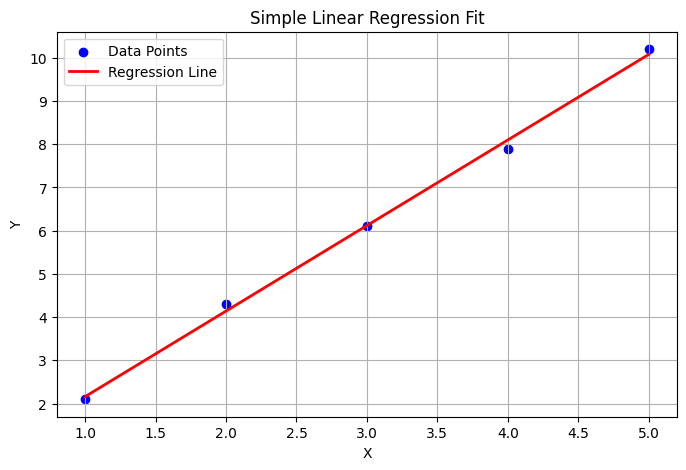

In [3]:
# Answer:-
import matplotlib.pyplot as plt
import numpy as np
from sklearn.linear_model import LinearRegression

# Sample data
X = np.array([1, 2, 3, 4, 5]).reshape(-1, 1)
Y = np.array([2.1, 4.3, 6.1, 7.9, 10.2])

# Fit Simple Linear Regression Model
model = LinearRegression()
model.fit(X, Y)

# Predictions
y_pred = model.predict(X)

# Print Model Results
print(f"Intercept (Beta 0): {model.intercept_:.4f}")
print(f"Coefficient (Beta 1): {model.coef_[0]:.4f}")

# Plotting
plt.figure(figsize=(8, 5))
plt.scatter(X, Y, color="blue", label="Data Points")
plt.plot(X, y_pred, color="red", linewidth=2, label="Regression Line")
plt.xlabel("X")
plt.ylabel("Y")
plt.title("Simple Linear Regression Fit")
plt.legend()
plt.grid(True)
plt.show()

In [4]:
# Question 7: Fit a Multiple Linear Regression model on this sample data:
Area = [1200, 1500, 1800, 2000]
Rooms = [2, 3, 3, 4]
Price = [250000, 300000, 320000, 370000]
#Check for multicollinearity using VIF and report the results.


In [6]:
# Answer:-
import pandas as pd
from sklearn.linear_model import LinearRegression
from statsmodels.stats.outliers_influence import variance_inflation_factor

# Sample Data
data = {
    "Area": [1200, 1500, 1800, 2000],
    "Rooms": [2, 3, 3, 4],
    "Price": [250000, 300000, 320000, 370000],
}
df = pd.DataFrame(data)

# Features and Target
X = df[["Area", "Rooms"]]
y = df["Price"]

# Fit Multiple Linear Regression
model = LinearRegression()
model.fit(X, y)

print(f"Intercept: {model.intercept_:.2f}")
print(f"Coefficients (Area, Rooms): {model.coef_}")

# Check for Multicollinearity using Variance Inflation Factor (VIF)
# Add constant for VIF calculation in statsmodels
X_vif = X.copy()
X_vif["Intercept"] = 1

vif_df = pd.DataFrame()
vif_df["Feature"] = X_vif.columns
vif_df["VIF"] = [
    variance_inflation_factor(X_vif.values, i) for i in range(X_vif.shape[1])
]

print("\n--- VIF Results ---")
print(vif_df[vif_df["Feature"] != "Intercept"])

Intercept: 103157.89
Coefficients (Area, Rooms): [   63.15789474 34736.84210526]

--- VIF Results ---
  Feature       VIF
0    Area  7.736842
1   Rooms  7.736842


In [7]:
# Question 8: Implement polynomial regression on the following data:
X = [1, 2, 3, 4, 5]

Y = [2.2, 4.8, 7.5, 11.2, 14.7]
#Fit a 2nd-degree polynomial and plot the resulting curve.

Polynomial Coefficients: [0.   1.94 0.2 ]
Intercept: 0.0600


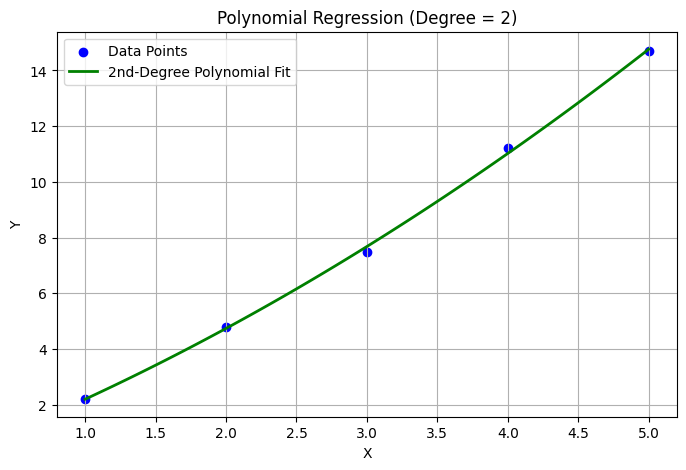

In [8]:
# Ans:-
import matplotlib.pyplot as plt
import numpy as np
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import PolynomialFeatures

# Data
X = np.array([1, 2, 3, 4, 5]).reshape(-1, 1)
Y = np.array([2.2, 4.8, 7.5, 11.2, 14.7])

# Transform features for 2nd Degree Polynomial
poly = PolynomialFeatures(degree=2)
X_poly = poly.fit_transform(X)

# Fit Regression Model
poly_model = LinearRegression()
poly_model.fit(X_poly, Y)

# Generate smooth line for plotting
X_smooth = np.linspace(1, 5, 100).reshape(-1, 1)
X_smooth_poly = poly.transform(X_smooth)
y_smooth_pred = poly_model.predict(X_smooth_poly)

# Output coefficients
print(f"Polynomial Coefficients: {poly_model.coef_}")
print(f"Intercept: {poly_model.intercept_:.4f}")

# Plot
plt.figure(figsize=(8, 5))
plt.scatter(X, Y, color="blue", label="Data Points")
plt.plot(
    X_smooth,
    y_smooth_pred,
    color="green",
    linewidth=2,
    label="2nd-Degree Polynomial Fit",
)
plt.xlabel("X")
plt.ylabel("Y")
plt.title("Polynomial Regression (Degree = 2)")
plt.legend()
plt.grid(True)
plt.show()

In [9]:
# Question 9: Create a residuals plot for a regression model trained on this data:
X = [10, 20, 30, 40, 50]
Y = [15, 35, 40, 50, 65]
# Assess heteroscedasticity by examining the spread of residuals.


<>:22: SyntaxWarning: invalid escape sequence '\h'
<>:23: SyntaxWarning: invalid escape sequence '\h'
<>:22: SyntaxWarning: invalid escape sequence '\h'
<>:23: SyntaxWarning: invalid escape sequence '\h'
/tmp/ipykernel_705/2452870287.py:22: SyntaxWarning: invalid escape sequence '\h'
  plt.xlabel("Predicted Values ($\hat{Y}$)")
/tmp/ipykernel_705/2452870287.py:23: SyntaxWarning: invalid escape sequence '\h'
  plt.ylabel("Residuals ($Y - \hat{Y}$)")


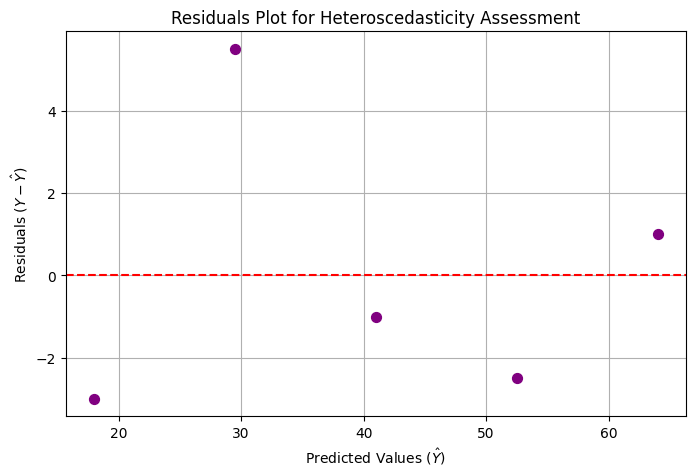

In [10]:
# Ans:-
import matplotlib.pyplot as plt
import numpy as np
from sklearn.linear_model import LinearRegression

# Data
X = np.array([10, 20, 30, 40, 50]).reshape(-1, 1)
Y = np.array([15, 35, 40, 50, 65])

# Train model
model = LinearRegression()
model.fit(X, Y)

# Predicted values and Residuals
y_pred = model.predict(X)
residuals = Y - y_pred

# Residual Plot
plt.figure(figsize=(8, 5))
plt.scatter(y_pred, residuals, color="purple", s=50)
plt.axhline(y=0, color="red", linestyle="--")
plt.xlabel("Predicted Values ($\hat{Y}$)")
plt.ylabel("Residuals ($Y - \hat{Y}$)")
plt.title("Residuals Plot for Heteroscedasticity Assessment")
plt.grid(True)
plt.show()

Question 10:  Imagine you are a data scientist working for a real estate company. You
need to predict house prices using features like area, number of rooms, and location.
However, you detect heteroscedasticity and multicollinearity in your regression
model. Explain the steps you would take to address these issues and ensure a robust
model.

 Ans:- When building real estate pricing models, heteroscedasticity often occurs because higher-priced mansions have significantly larger price variations than entry-level homes. Multicollinearity occurs because Area and Rooms are highly correlated.

Here are the concrete engineering steps to address both issues:

1. Addressing Heteroscedasticity

:- Target Transformation: Apply a non-linear log transformation to the target variable ($\log(Y)$). Log-transforming housing prices stabilizes price variance across different price points.

:- Weighted Least Squares (WLS): Use WLS regression, where observations with higher variance receive lower weights.

:- Robust Standard Errors: Utilize Heteroscedasticity-Consistent (HC) robust standard errors (e.g., White’s standard errors / HC3) during hypothesis testing to correct $p$-values without altering coefficient estimates.

2. Addressing Multicollinearity

:- Feature Selection / Removal: Calculate Variance Inflation Factors (VIF). Drop or combine redundant features (e.g., keeping Area while dropping Rooms or creating a derived feature like Average Room Size = Area / Rooms).

:- Regularization Techniques: Use Ridge (L2) or ElasticNet regression. Ridge regression introduces a penalty on large coefficients, effectively stabilizing predictions even under high multicollinearity.

:- Dimensionality Reduction: Use Principal Component Analysis (PCA) to transform correlated features into orthogonal, uncorrelated principal components.